In [3]:
#1. import libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import yfinance as yf

#2. import dataset 1 year of daily data btc
ticker = "BTC-USD"
data = yf.download(ticker, period="1y", interval="1d")

#3. view if it worked
data.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
Date,,,,,
2025-03-04,87222.195312,88911.273438,81529.242188,86064.070312,68095241474
2025-03-05,90623.562500,90998.242188,86379.773438,87222.953125,50498988027
2025-03-06,89961.726562,92804.937500,87852.140625,90622.359375,47749810486
2025-03-07,86742.671875,91191.046875,84717.679688,89963.281250,65945677657
2025-03-08,86154.593750,86847.265625,85247.484375,86742.656250,18206118081


In [7]:
# 1. Isolate the exact 1D Series by chaining brackets: [Metric][Ticker]
close_prices = data['Close']['BTC-USD']

# 2. Shift that specific 1D Series down by 1 row
yesterday_prices = close_prices.shift(1)

# 3. Apply the math formula and assign it to your new column
data['Manual_Returns'] = (close_prices - yesterday_prices) / yesterday_prices

# 1. Calculate Simple Returns
data['Returns'] = data['Close'].pct_change()

# View the results!
data.head()





Price,Close,High,Low,Open,Volume,Yesterday_Close,Manual_Returns,Returns
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD,,,
Date,,,,,,,,
2025-03-04,87222.195312,88911.273438,81529.242188,86064.070312,68095241474,NaN,NaN,NaN
2025-03-05,90623.562500,90998.242188,86379.773438,87222.953125,50498988027,87222.195312,0.038997,0.038997
2025-03-06,89961.726562,92804.937500,87852.140625,90622.359375,47749810486,90623.562500,-0.007303,-0.007303
2025-03-07,86742.671875,91191.046875,84717.679688,89963.281250,65945677657,89961.726562,-0.035782,-0.035782
2025-03-08,86154.593750,86847.265625,85247.484375,86742.656250,18206118081,86742.671875,-0.006780,-0.006780


In [10]:
# 1. Calculate Simple Returns
data['Returns'] = data['Close'].pct_change()

# 2. Calculate Log-Returns
data['Log_Returns'] = np.log(data['Close'] / data['Close'].shift(1))

# 3. Calculate 20-day Volatility
data['Volatility'] = data['Log_Returns'].rolling(window=20).std()

# 4. Calculate Body-to-Wick Ratio
body = np.abs(data['Close'] - data['Open'])
wick = data['High'] - data['Low']
data['Body_Wick_Ratio'] = body / (wick + 1e-8) # 1e-8 prevents division by zero

# 5. Clean the data
# The pct_change() and rolling() functions require historical data, 
# which creates empty (NaN) rows at the top of our dataset. We must drop them.
data = data.dropna()

# View the new features
data[['Open', 'Close', 'Returns', 'Log_Returns', 'Volatility', 'Body_Wick_Ratio']].head()

Price,Open,Close,Returns,Log_Returns,Volatility,Body_Wick_Ratio
Ticker,BTC-USD,BTC-USD,,,,
Date,,,,,,
2025-05-01,94212.859375,96492.335938,0.024255,0.023966,0.018074,0.694047
2025-05-02,96494.968750,96910.070312,0.004329,0.004320,0.017731,0.271317
2025-05-03,96904.632812,95891.796875,-0.010507,-0.010563,0.017190,0.902228
2025-05-04,95877.187500,94315.976562,-0.016433,-0.016570,0.017938,0.727670
2025-05-05,94319.562500,94748.054688,0.004581,0.004571,0.017550,0.263376


In [11]:
from statsmodels.tsa.stattools import adfuller

def run_adf_test(column_name, series):
    print(f"--- ADF Test for: {column_name} ---")
    # drop any remaining NaNs just in case
    result = adfuller(series.dropna())
    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"p-value: {result[1]:.4f}")
    
    if result[1] <= 0.05:
        print("Result: Stationary (Reject Null Hypothesis)")
    else:
        print("Result: Non-Stationary (Fail to Reject Null Hypothesis)")
    print("\n")

# Run the test on our main features
run_adf_test("Raw Close Price", data['Close'])
run_adf_test("Simple Returns", data['Returns'])
run_adf_test("Log Returns", data['Log_Returns'])
run_adf_test("20-Day Volatility", data['Volatility'])
run_adf_test("Body-to-Wick Ratio", data['Body_Wick_Ratio'])

--- ADF Test for: Raw Close Price ---
ADF Statistic: -0.5295
p-value: 0.8861
Result: Non-Stationary (Fail to Reject Null Hypothesis)


--- ADF Test for: Simple Returns ---
ADF Statistic: -18.5725
p-value: 0.0000
Result: Stationary (Reject Null Hypothesis)


--- ADF Test for: Log Returns ---
ADF Statistic: -18.5087
p-value: 0.0000
Result: Stationary (Reject Null Hypothesis)


--- ADF Test for: 20-Day Volatility ---
ADF Statistic: -2.4436
p-value: 0.1298
Result: Non-Stationary (Fail to Reject Null Hypothesis)


--- ADF Test for: Body-to-Wick Ratio ---
ADF Statistic: -18.5012
p-value: 0.0000
Result: Stationary (Reject Null Hypothesis)




<class 'pandas.DataFrame'>
<class 'pandas.Series'>
[('Close', 'BTC-USD'), ('High', 'BTC-USD'), ('Low', 'BTC-USD'), ('Open', 'BTC-USD'), ('Volume', 'BTC-USD'), ('Yesterday_Close', ''), ('Manual_Returns', ''), ('Returns', ''), ('Log_Returns', ''), ('Volatility', ''), ('Body_Wick_Ratio', '')]


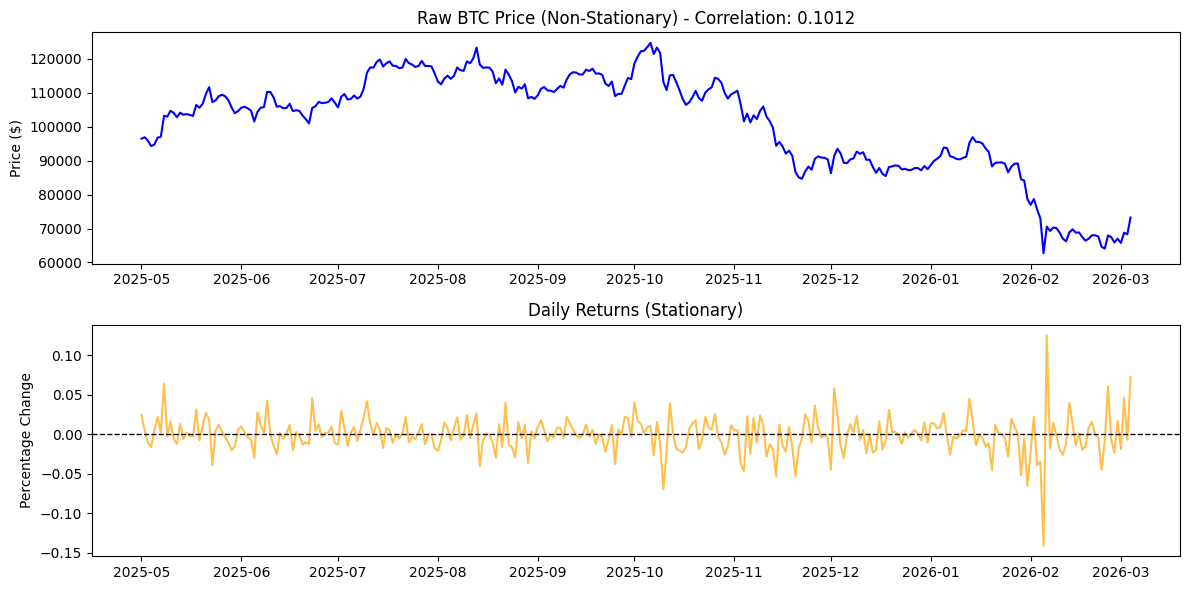

In [15]:
print(type(data['Close']))    # Should say: <class 'pandas.core.series.Series'>
print(type(data['Returns']))  # Should say: <class 'pandas.core.series.Series'>
print(data.columns.tolist())  # Check for duplicate column names

data.columns = [col[0] for col in data.columns]

correlation = data['Close'].squeeze().corr(data['Returns'].squeeze())

# Calculate correlation
correlation = data['Close'].corr(data['Returns'])

# Plotting
plt.figure(figsize=(12, 6))

# Subplot 1: Raw Price (The Trend)
plt.subplot(2, 1, 1)
plt.plot(data['Close'], color='blue')
plt.title(f"Raw BTC Price (Non-Stationary) - Correlation: {correlation:.4f}")
plt.ylabel("Price ($)")

# Subplot 2: Returns (The Signal)
plt.subplot(2, 1, 2)
plt.plot(data['Returns'], color='orange', alpha=0.7)
plt.axhline(0, color='black', linestyle='--', lw=1)
plt.title("Daily Returns (Stationary)")
plt.ylabel("Percentage Change")

plt.tight_layout()
plt.show()

In [14]:
print(type(data['Close']))    # Should say: <class 'pandas.core.series.Series'>
print(type(data['Returns']))  # Should say: <class 'pandas.core.series.Series'>
print(data.columns.tolist())  # Check for duplicate column names

<class 'pandas.DataFrame'>
<class 'pandas.Series'>
[('Close', 'BTC-USD'), ('High', 'BTC-USD'), ('Low', 'BTC-USD'), ('Open', 'BTC-USD'), ('Volume', 'BTC-USD'), ('Yesterday_Close', ''), ('Manual_Returns', ''), ('Returns', ''), ('Log_Returns', ''), ('Volatility', ''), ('Body_Wick_Ratio', '')]
